In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2024)

N = 3000

cities = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Челябинск"]
categories = ["Электроника", "Одежда", "Дом", "Красота", "Спорт"]
statuses = ["Доставлен", "Отменён", "Возврат"]
payments = ["Карта", "Онлайн", "Наличные"]

products = {
    "Электроника": ["Смартфон", "Ноутбук", "Наушники", "Планшет", "Телевизор"],
    "Одежда":      ["Футболка", "Джинсы", "Куртка", "Платье", "Кроссовки"],
    "Дом":         ["Пылесос", "Чайник", "Кастрюля", "Лампа", "Подушка"],
    "Красота":     ["Крем", "Шампунь", "Парфюм", "Помада", "Маска"],
    "Спорт":       ["Гантели", "Коврик", "Скакалка", "Велосипед", "Мяч"],
}

dates = pd.date_range("2023-01-01", "2024-12-31", freq="D")

df = pd.DataFrame({
    "order_id":     np.arange(1, N + 1),
    "order_date":   np.random.choice(dates, N),
    "customer_id":  np.random.randint(1, 800, N),
    "city":         np.random.choice(cities, N, p=[0.4, 0.25, 0.15, 0.12, 0.08]),
    "age":          np.random.randint(18, 70, N).astype(float),
    "is_vip":       np.random.choice([True, False], N, p=[0.2, 0.8]),
    "product_name": np.nan,
    "category":     np.random.choice(categories, N),
    "quantity":     np.random.randint(1, 6, N),
    "price":        np.round(np.random.uniform(200, 15000, N), 2),
    "discount":     np.round(np.random.uniform(0, 0.4, N), 2),
    "cost":         np.round(np.random.uniform(100, 12000, N), 2),
    "status":       np.random.choice(statuses, N, p=[0.75, 0.15, 0.10]),
    "payment":      np.random.choice(payments, N, p=[0.5, 0.3, 0.2]),
})

df["product_name"] = df["category"].apply(lambda c: np.random.choice(products[c]))

missing_idx = np.random.choice(df.index, 30, replace=False)
df.loc[missing_idx, "age"] = np.nan

# Часть 1. Первичный анализ данных

In [ ]:
print(df.shape)
print(df.info())
print(df.head())
print(df.tail())
print(df.describe())
print(df.isna().sum())
print('------')
print(df['customer_id'].nunique())
print(df['product_name'].nunique())
print(df['city'].unique())
print(df['category'].unique())
print(df['payment'].unique())

(3000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3000 non-null   int64         
 1   order_date    3000 non-null   datetime64[ns]
 2   customer_id   3000 non-null   int64         
 3   city          3000 non-null   object        
 4   age           2970 non-null   float64       
 5   is_vip        3000 non-null   bool          
 6   product_name  3000 non-null   object        
 7   category      3000 non-null   object        
 8   quantity      3000 non-null   int64         
 9   price         3000 non-null   float64       
 10  discount      3000 non-null   float64       
 11  cost          3000 non-null   float64       
 12  status        3000 non-null   object        
 13  payment       3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(3), object(5)
memory usage: 

1. 3000 cтрок, 14 столбцов
2. в age
3. 30
4. 780
5. 25
6. 'Москва' 'Екатеринбург' 'Челябинск' 'Санкт-Петербург' 'Казань']
7. ['Красота' 'Одежда' 'Дом' 'Спорт' 'Электроника']
8. ['Карта' 'Онлайн' 'Наличные']

# Часть 2. Подготовка данных

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

In [ ]:
df['revenue'] = (df['price'] * df['quantity'] * (1 - df['discount']))
df['profit'] = df['revenue'] - df['cost']

In [ ]:
df['is_real_sale'] = df['status'] == 'Доставлен'

In [ ]:
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
df['age'].isna().sum()

np.int64(0)

In [ ]:
bins = [0, 18, 30, 45, 60, 100]
labels = [
    'до 18',
    '18-30',
    '31-45',
    '46-60',
    '60+'
]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
df['age_group'].value_counts()

,count
age_group,
46-60,886
31-45,854
18-35,708
60+,497
до 18,55


# Часть 3. Фильтрация данных

In [ ]:
df[df['quantity'] > 3]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,458,Москва,45.0,False,Шампунь,Красота,4,11549.55,0.26,10268.60,Доставлен,Карта,2024,10,34186.6680,23918.0680,True,31-45
1,2,2024-05-21,560,Москва,29.0,False,Кроссовки,Одежда,5,5332.20,0.05,1772.80,Отменён,Карта,2024,5,25327.9500,23555.1500,False,18-35
2,3,2024-08-31,753,Москва,42.0,True,Подушка,Дом,5,13264.11,0.33,6684.91,Доставлен,Карта,2024,8,44434.7685,37749.8585,True,31-45
4,5,2024-06-23,150,Екатеринбург,43.0,False,Ноутбук,Электроника,4,13247.03,0.08,4952.04,Отменён,Онлайн,2024,6,48749.0704,43797.0304,False,31-45
8,9,2023-05-08,101,Москва,58.0,False,Телевизор,Электроника,4,6506.68,0.32,10851.78,Доставлен,Онлайн,2023,5,17698.1696,6846.3896,True,46-60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992,2993,2024-04-02,504,Казань,31.0,False,Скакалка,Спорт,5,7556.74,0.06,5394.93,Отменён,Наличные,2024,4,35516.6780,30121.7480,False,31-45
2993,2994,2023-12-04,197,Казань,36.0,False,Шампунь,Красота,5,1136.37,0.13,10783.85,Доставлен,Карта,2023,12,4943.2095,-5840.6405,True,31-45
2995,2996,2024-01-12,414,Санкт-Петербург,29.0,True,Крем,Красота,5,12039.43,0.34,8564.66,Возврат,Карта,2024,1,39730.1190,31165.4590,False,18-35
2997,2998,2024-02-27,116,Санкт-Петербург,66.0,False,Коврик,Спорт,5,13639.38,0.21,4250.50,Возврат,Карта,2024,2,53875.5510,49625.0510,False,60+


In [ ]:
df[df['city'] == 'Москва']

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,458,Москва,45.0,False,Шампунь,Красота,4,11549.55,0.26,10268.60,Доставлен,Карта,2024,10,34186.6680,23918.0680,True,31-45
1,2,2024-05-21,560,Москва,29.0,False,Кроссовки,Одежда,5,5332.20,0.05,1772.80,Отменён,Карта,2024,5,25327.9500,23555.1500,False,18-35
2,3,2024-08-31,753,Москва,42.0,True,Подушка,Дом,5,13264.11,0.33,6684.91,Доставлен,Карта,2024,8,44434.7685,37749.8585,True,31-45
5,6,2024-07-02,750,Москва,58.0,False,Подушка,Дом,3,13021.93,0.28,11970.70,Отменён,Карта,2024,7,28127.3688,16156.6688,False,46-60
6,7,2024-03-22,247,Москва,56.0,False,Чайник,Дом,2,6988.98,0.33,6399.47,Отменён,Онлайн,2024,3,9365.2332,2965.7632,False,46-60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2981,2982,2023-10-08,48,Москва,28.0,False,Помада,Красота,4,9875.60,0.13,3537.91,Доставлен,Карта,2023,10,34367.0880,30829.1780,True,18-35
2982,2983,2023-05-27,38,Москва,29.0,True,Пылесос,Дом,4,816.40,0.20,5937.29,Доставлен,Карта,2023,5,2612.4800,-3324.8100,True,18-35
2985,2986,2024-02-19,253,Москва,49.0,False,Наушники,Электроника,5,8031.93,0.14,6720.07,Доставлен,Карта,2024,2,34537.2990,27817.2290,True,46-60
2989,2990,2023-08-15,758,Москва,23.0,False,Футболка,Одежда,2,14109.97,0.08,2174.52,Доставлен,Карта,2023,8,25962.3448,23787.8248,True,18-35


In [ ]:
df[df['is_vip']]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
2,3,2024-08-31,753,Москва,42.0,True,Подушка,Дом,5,13264.11,0.33,6684.91,Доставлен,Карта,2024,8,44434.7685,37749.8585,True,31-45
11,12,2023-03-16,408,Москва,53.0,True,Помада,Красота,3,13289.92,0.24,11469.79,Доставлен,Онлайн,2023,3,30301.0176,18831.2276,True,46-60
16,17,2024-01-03,720,Челябинск,51.0,True,Куртка,Одежда,4,14724.40,0.19,7499.74,Доставлен,Карта,2024,1,47707.0560,40207.3160,True,46-60
17,18,2023-09-05,725,Москва,22.0,True,Планшет,Электроника,5,14937.85,0.03,3669.56,Возврат,Онлайн,2023,9,72448.5725,68779.0125,False,18-35
20,21,2023-12-18,582,Екатеринбург,18.0,True,Футболка,Одежда,5,13611.91,0.01,2527.37,Возврат,Онлайн,2023,12,67378.9545,64851.5845,False,до 18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2968,2969,2023-12-29,779,Екатеринбург,47.0,True,Лампа,Дом,5,12542.99,0.22,1328.88,Доставлен,Карта,2023,12,48917.6610,47588.7810,True,46-60
2975,2976,2024-10-17,633,Москва,37.0,True,Подушка,Дом,1,3250.33,0.29,699.97,Доставлен,Карта,2024,10,2307.7343,1607.7643,True,31-45
2982,2983,2023-05-27,38,Москва,29.0,True,Пылесос,Дом,4,816.40,0.20,5937.29,Доставлен,Карта,2023,5,2612.4800,-3324.8100,True,18-35
2990,2991,2023-01-05,246,Челябинск,54.0,True,Куртка,Одежда,1,2403.31,0.36,10758.94,Доставлен,Карта,2023,1,1538.1184,-9220.8216,True,46-60


In [ ]:
df[df['price'] > 5000]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,458,Москва,45.0,False,Шампунь,Красота,4,11549.55,0.26,10268.60,Доставлен,Карта,2024,10,34186.6680,23918.0680,True,31-45
1,2,2024-05-21,560,Москва,29.0,False,Кроссовки,Одежда,5,5332.20,0.05,1772.80,Отменён,Карта,2024,5,25327.9500,23555.1500,False,18-35
2,3,2024-08-31,753,Москва,42.0,True,Подушка,Дом,5,13264.11,0.33,6684.91,Доставлен,Карта,2024,8,44434.7685,37749.8585,True,31-45
3,4,2024-10-02,723,Екатеринбург,53.0,False,Скакалка,Спорт,3,5922.81,0.17,1532.11,Отменён,Онлайн,2024,10,14747.7969,13215.6869,False,46-60
4,5,2024-06-23,150,Екатеринбург,43.0,False,Ноутбук,Электроника,4,13247.03,0.08,4952.04,Отменён,Онлайн,2024,6,48749.0704,43797.0304,False,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,2995,2023-05-02,583,Казань,38.0,False,Шампунь,Красота,1,6556.29,0.17,3023.26,Доставлен,Карта,2023,5,5441.7207,2418.4607,True,31-45
2995,2996,2024-01-12,414,Санкт-Петербург,29.0,True,Крем,Красота,5,12039.43,0.34,8564.66,Возврат,Карта,2024,1,39730.1190,31165.4590,False,18-35
2997,2998,2024-02-27,116,Санкт-Петербург,66.0,False,Коврик,Спорт,5,13639.38,0.21,4250.50,Возврат,Карта,2024,2,53875.5510,49625.0510,False,60+
2998,2999,2023-08-14,589,Санкт-Петербург,18.0,False,Парфюм,Красота,1,5298.17,0.14,7800.83,Доставлен,Карта,2023,8,4556.4262,-3244.4038,True,до 18


In [ ]:
df[df['discount'] > 0.2]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,458,Москва,45.0,False,Шампунь,Красота,4,11549.55,0.26,10268.60,Доставлен,Карта,2024,10,34186.6680,23918.0680,True,31-45
2,3,2024-08-31,753,Москва,42.0,True,Подушка,Дом,5,13264.11,0.33,6684.91,Доставлен,Карта,2024,8,44434.7685,37749.8585,True,31-45
5,6,2024-07-02,750,Москва,58.0,False,Подушка,Дом,3,13021.93,0.28,11970.70,Отменён,Карта,2024,7,28127.3688,16156.6688,False,46-60
6,7,2024-03-22,247,Москва,56.0,False,Чайник,Дом,2,6988.98,0.33,6399.47,Отменён,Онлайн,2024,3,9365.2332,2965.7632,False,46-60
8,9,2023-05-08,101,Москва,58.0,False,Телевизор,Электроника,4,6506.68,0.32,10851.78,Доставлен,Онлайн,2023,5,17698.1696,6846.3896,True,46-60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988,2989,2023-07-15,268,Екатеринбург,21.0,False,Планшет,Электроника,1,9593.41,0.24,1234.72,Доставлен,Онлайн,2023,7,7290.9916,6056.2716,True,18-35
2990,2991,2023-01-05,246,Челябинск,54.0,True,Куртка,Одежда,1,2403.31,0.36,10758.94,Доставлен,Карта,2023,1,1538.1184,-9220.8216,True,46-60
2991,2992,2023-11-07,513,Санкт-Петербург,24.0,False,Парфюм,Красота,2,6302.40,0.35,6540.49,Доставлен,Карта,2023,11,8193.1200,1652.6300,True,18-35
2995,2996,2024-01-12,414,Санкт-Петербург,29.0,True,Крем,Красота,5,12039.43,0.34,8564.66,Возврат,Карта,2024,1,39730.1190,31165.4590,False,18-35


In [ ]:
df['status'].value_counts()

,count
status,
Доставлен,2249
Отменён,428
Возврат,323


In [ ]:
df[df['is_vip'] & (df['category'] == 'Электроника')]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
17,18,2023-09-05,725,Москва,22.0,True,Планшет,Электроника,5,14937.85,0.03,3669.56,Возврат,Онлайн,2023,9,72448.5725,68779.0125,False,18-35
23,24,2023-04-02,544,Санкт-Петербург,57.0,True,Планшет,Электроника,3,3296.49,0.12,6880.51,Доставлен,Карта,2023,4,8702.7336,1822.2236,True,46-60
43,44,2023-04-08,366,Москва,69.0,True,Смартфон,Электроника,4,6705.05,0.24,4195.78,Возврат,Онлайн,2023,4,20383.3520,16187.5720,False,60+
98,99,2023-08-01,445,Казань,27.0,True,Ноутбук,Электроника,3,1565.35,0.35,6925.03,Доставлен,Наличные,2023,8,3052.4325,-3872.5975,True,18-35
115,116,2023-01-07,584,Челябинск,59.0,True,Ноутбук,Электроника,5,14404.63,0.29,2065.57,Доставлен,Карта,2023,1,51136.4365,49070.8665,True,46-60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2913,2024-03-16,734,Екатеринбург,57.0,True,Телевизор,Электроника,1,3216.73,0.09,6526.32,Доставлен,Карта,2024,3,2927.2243,-3599.0957,True,46-60
2918,2919,2024-05-26,372,Екатеринбург,53.0,True,Телевизор,Электроника,3,10514.08,0.25,173.05,Доставлен,Наличные,2024,5,23656.6800,23483.6300,True,46-60
2940,2941,2024-04-23,544,Екатеринбург,38.0,True,Наушники,Электроника,2,5843.79,0.20,11379.24,Возврат,Наличные,2024,4,9350.0640,-2029.1760,False,31-45
2948,2949,2023-10-06,171,Москва,48.0,True,Смартфон,Электроника,1,7428.35,0.32,5392.12,Доставлен,Наличные,2023,10,5051.2780,-340.8420,True,46-60


In [ ]:
df[(df['status'] == 'Доставлен') & (df['payment'] == 'Онлайн')]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
8,9,2023-05-08,101,Москва,58.0,False,Телевизор,Электроника,4,6506.68,0.32,10851.78,Доставлен,Онлайн,2023,5,17698.1696,6846.3896,True,46-60
11,12,2023-03-16,408,Москва,53.0,True,Помада,Красота,3,13289.92,0.24,11469.79,Доставлен,Онлайн,2023,3,30301.0176,18831.2276,True,46-60
14,15,2024-05-23,220,Москва,28.0,False,Гантели,Спорт,4,4578.19,0.14,6007.41,Доставлен,Онлайн,2024,5,15748.9736,9741.5636,True,18-35
24,25,2023-02-09,772,Москва,23.0,True,Велосипед,Спорт,2,14578.00,0.29,8351.40,Доставлен,Онлайн,2023,2,20700.7600,12349.3600,True,18-35
33,34,2024-08-04,186,Санкт-Петербург,60.0,False,Мяч,Спорт,3,14136.58,0.14,6767.19,Доставлен,Онлайн,2024,8,36472.3764,29705.1864,True,46-60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2957,2958,2023-01-11,253,Санкт-Петербург,41.0,True,Коврик,Спорт,2,10567.75,0.05,7611.95,Доставлен,Онлайн,2023,1,20078.7250,12466.7750,True,31-45
2970,2971,2023-02-06,209,Челябинск,38.0,False,Кроссовки,Одежда,2,10878.85,0.29,7882.65,Доставлен,Онлайн,2023,2,15447.9670,7565.3170,True,31-45
2979,2980,2024-02-01,115,Москва,47.0,False,Подушка,Дом,5,12214.58,0.02,9025.47,Доставлен,Онлайн,2024,2,59851.4420,50825.9720,True,46-60
2988,2989,2023-07-15,268,Екатеринбург,21.0,False,Планшет,Электроника,1,9593.41,0.24,1234.72,Доставлен,Онлайн,2023,7,7290.9916,6056.2716,True,18-35


In [ ]:
df[df['year'] == 2024]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,458,Москва,45.0,False,Шампунь,Красота,4,11549.55,0.26,10268.60,Доставлен,Карта,2024,10,34186.6680,23918.0680,True,31-45
1,2,2024-05-21,560,Москва,29.0,False,Кроссовки,Одежда,5,5332.20,0.05,1772.80,Отменён,Карта,2024,5,25327.9500,23555.1500,False,18-35
2,3,2024-08-31,753,Москва,42.0,True,Подушка,Дом,5,13264.11,0.33,6684.91,Доставлен,Карта,2024,8,44434.7685,37749.8585,True,31-45
3,4,2024-10-02,723,Екатеринбург,53.0,False,Скакалка,Спорт,3,5922.81,0.17,1532.11,Отменён,Онлайн,2024,10,14747.7969,13215.6869,False,46-60
4,5,2024-06-23,150,Екатеринбург,43.0,False,Ноутбук,Электроника,4,13247.03,0.08,4952.04,Отменён,Онлайн,2024,6,48749.0704,43797.0304,False,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992,2993,2024-04-02,504,Казань,31.0,False,Скакалка,Спорт,5,7556.74,0.06,5394.93,Отменён,Наличные,2024,4,35516.6780,30121.7480,False,31-45
2995,2996,2024-01-12,414,Санкт-Петербург,29.0,True,Крем,Красота,5,12039.43,0.34,8564.66,Возврат,Карта,2024,1,39730.1190,31165.4590,False,18-35
2996,2997,2024-02-03,146,Москва,67.0,False,Мяч,Спорт,2,1111.13,0.11,10547.30,Доставлен,Карта,2024,2,1977.8114,-8569.4886,True,60+
2997,2998,2024-02-27,116,Санкт-Петербург,66.0,False,Коврик,Спорт,5,13639.38,0.21,4250.50,Возврат,Карта,2024,2,53875.5510,49625.0510,False,60+


In [ ]:
df[(df['year'] == 2024) & (df['month'] == 1)]

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
16,17,2024-01-03,720,Челябинск,51.0,True,Куртка,Одежда,4,14724.40,0.19,7499.74,Доставлен,Карта,2024,1,47707.0560,40207.3160,True,46-60
21,22,2024-01-03,333,Казань,30.0,True,Велосипед,Спорт,4,1767.90,0.23,7986.91,Доставлен,Наличные,2024,1,5445.1320,-2541.7780,True,18-35
41,42,2024-01-18,275,Москва,23.0,True,Шампунь,Красота,5,559.72,0.14,7562.61,Доставлен,Карта,2024,1,2406.7960,-5155.8140,True,18-35
44,45,2024-01-27,44,Москва,69.0,False,Коврик,Спорт,2,4643.12,0.34,3177.61,Доставлен,Онлайн,2024,1,6128.9184,2951.3084,True,60+
49,50,2024-01-20,91,Казань,31.0,False,Коврик,Спорт,1,8279.67,0.23,5714.02,Доставлен,Онлайн,2024,1,6375.3459,661.3259,True,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2889,2890,2024-01-25,153,Санкт-Петербург,42.0,False,Кроссовки,Одежда,3,14170.35,0.08,2173.78,Доставлен,Онлайн,2024,1,39110.1660,36936.3860,True,31-45
2921,2922,2024-01-09,18,Челябинск,57.0,True,Пылесос,Дом,3,11992.59,0.27,918.96,Доставлен,Онлайн,2024,1,26263.7721,25344.8121,True,46-60
2953,2954,2024-01-22,211,Казань,26.0,False,Лампа,Дом,5,4182.65,0.35,7925.83,Доставлен,Карта,2024,1,13593.6125,5667.7825,True,18-35
2986,2987,2024-01-10,69,Санкт-Петербург,31.0,False,Лампа,Дом,1,5998.98,0.21,6099.34,Доставлен,Карта,2024,1,4739.1942,-1360.1458,True,31-45


**Поиск экстремальных значений**

In [ ]:
# 1
df.loc[df['revenue'].idxmax()]

,17
order_id,18
order_date,2023-09-05 00:00:00
customer_id,725
city,Москва
age,22.0
is_vip,True
product_name,Планшет
category,Электроника
quantity,5
price,14937.85


In [ ]:
# 2
df.loc[df['discount'].idxmax()]

,127
order_id,128
order_date,2023-05-27 00:00:00
customer_id,70
city,Санкт-Петербург
age,36.0
is_vip,False
product_name,Куртка
category,Одежда
quantity,2
price,12341.71


In [ ]:
# 3
df.loc[df['profit'].idxmax()]

,17
order_id,18
order_date,2023-09-05 00:00:00
customer_id,725
city,Москва
age,22.0
is_vip,True
product_name,Планшет
category,Электроника
quantity,5
price,14937.85


In [ ]:
# 4
df.loc[df['age'].idxmin()]

,15
order_id,16
order_date,2023-06-08 00:00:00
customer_id,497
city,Москва
age,18.0
is_vip,False
product_name,Чайник
category,Дом
quantity,3
price,14210.16


In [ ]:
# 5
df.loc[df['age'].idxmax()]

,43
order_id,44
order_date,2023-04-08 00:00:00
customer_id,366
city,Москва
age,69.0
is_vip,True
product_name,Смартфон
category,Электроника
quantity,4
price,6705.05


# Часть 4. Группировка данных

In [ ]:
# 1
df.groupby("category")['revenue'].sum()

,revenue
category,
Дом,1.184381e+07
Красота,1.035824e+07
Одежда,1.094603e+07
Спорт,1.237715e+07
Электроника,1.065094e+07


спорт имеет наибольшую выручку

In [ ]:
# 2
df.groupby('category')['revenue'].mean()

,revenue
category,
Дом,19072.156937
Красота,17497.019923
Одежда,19136.419169
Спорт,19803.447344
Электроника,18052.440760


In [ ]:
# 3
df.groupby('category')['order_id'].count()

,order_id
category,
Дом,621
Красота,592
Одежда,572
Спорт,625
Электроника,590


In [ ]:
# 4
df.groupby('category')['discount'].mean()

,discount
category,
Дом,0.190113
Красота,0.193024
Одежда,0.193549
Спорт,0.193056
Электроника,0.198898


In [ ]:
# 5
df.groupby(['category', 'city'])['revenue'].sum()

category     city           
Дом          Екатеринбург       1.469764e+06
             Казань             1.663314e+06
             Москва             5.268453e+06
             Санкт-Петербург    2.437813e+06
             Челябинск          1.004466e+06
Красота      Екатеринбург       9.383149e+05
             Казань             1.784714e+06
             Москва             4.431582e+06
             Санкт-Петербург    2.558745e+06
             Челябинск          6.448796e+05
Одежда       Екатеринбург       1.271668e+06
             Казань             1.325076e+06
             Москва             4.769972e+06
             Санкт-Петербург    2.462265e+06
             Челябинск          1.117050e+06
Спорт        Екатеринбург       1.870590e+06
             Казань             2.339727e+06
             Москва             4.858414e+06
             Санкт-Петербург    2.432609e+06
             Челябинск          8.758151e+05
Электроника  Екатеринбург       1.451960e+06
             Казань             1.611751e+06
             Москва             4.123366e+06
             Санкт-Петербург    2.862138e+06
             Челябинск          6.017242e+05
Name: revenue, dtype: float64

In [ ]:
# 6
df[df['is_vip']].groupby('city')['revenue'].mean()

,revenue
city,
Екатеринбург,18953.118485
Казань,18211.932197
Москва,18001.732872
Санкт-Петербург,17315.010581
Челябинск,20460.245181


In [ ]:
# 7
df.groupby(['city', 'payment'])['order_id'].count()

city             payment 
Екатеринбург     Карта       174
                 Наличные     86
                 Онлайн      125
Казань           Карта       224
                 Наличные    100
                 Онлайн      141
Москва           Карта       633
                 Наличные    223
                 Онлайн      343
Санкт-Петербург  Карта       354
                 Наличные    140
                 Онлайн      214
Челябинск        Карта       120
                 Наличные     52
                 Онлайн       71
Name: order_id, dtype: int64

In [ ]:
# 8
df.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_discount=("discount", "mean"),
    profit=("profit", "sum"),
)

,orders,revenue,avg_revenue,avg_discount,profit
category,,,,,
Дом,621,1.184381e+07,19072.156937,0.190113,8.134255e+06
Красота,592,1.035824e+07,17497.019923,0.193024,6.752573e+06
Одежда,572,1.094603e+07,19136.419169,0.193549,7.513991e+06
Спорт,625,1.237715e+07,19803.447344,0.193056,8.493972e+06
Электроника,590,1.065094e+07,18052.440760,0.198898,7.010110e+06


# Часть 5. Визуализация

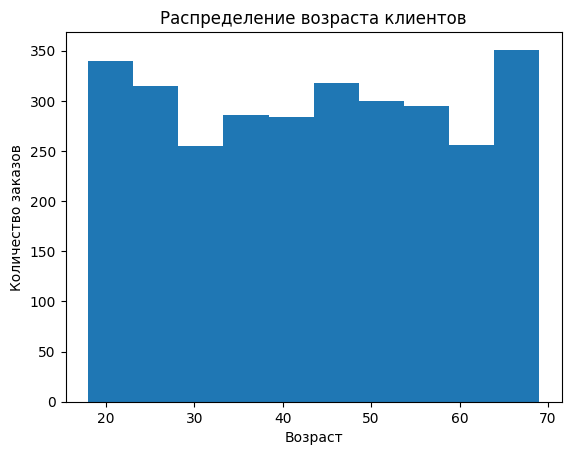

In [ ]:
import matplotlib.pyplot as plt

# 1
plt.hist(df['age'], bins=10)
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество заказов')
plt.show()

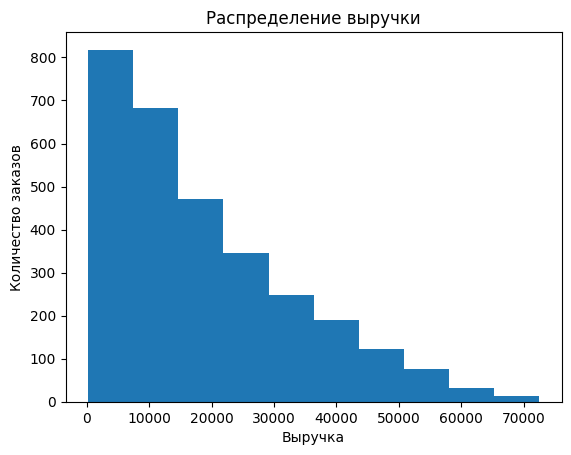

In [ ]:
plt.hist(df['revenue'])
plt.title('Распределение выручки')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')
plt.show()

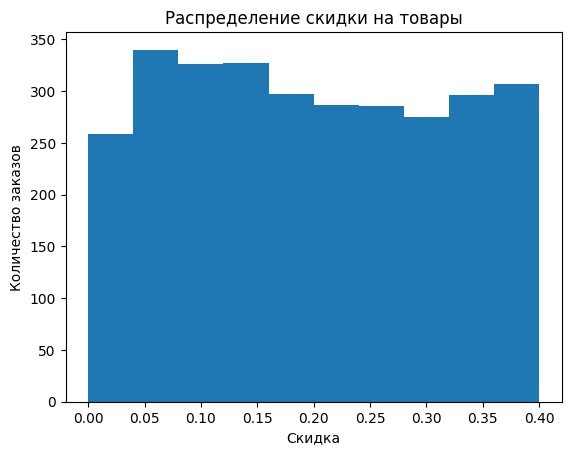

In [ ]:
plt.hist(df['discount'])
plt.title('Распределение скидки на товары')
plt.xlabel('Скидка')
plt.ylabel('Количество заказов')
plt.show()

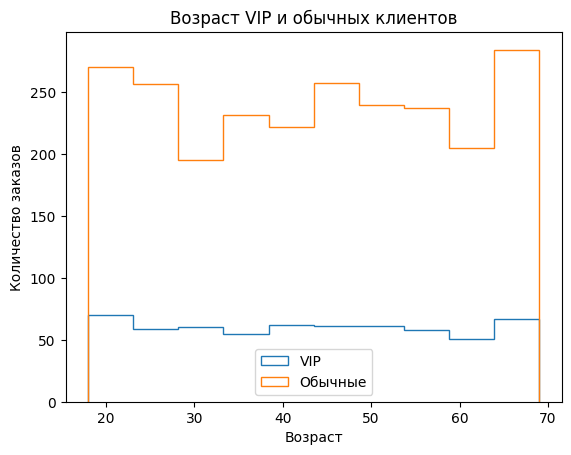

In [ ]:
plt.hist(df[df["is_vip"]]["age"], label="VIP", histtype="step")
plt.hist(df[~df["is_vip"]]["age"], label="Обычные", histtype="step")
plt.title("Возраст VIP и обычных клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.legend()
plt.show()

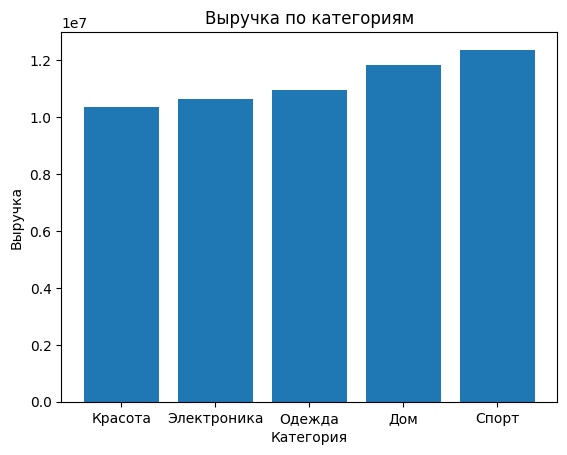

In [ ]:
s5 = df.groupby("category")["revenue"].sum().sort_values()
plt.bar(s5.index, s5.values)
plt.title("Выручка по категориям")
plt.xlabel("Категория")
plt.ylabel("Выручка")
plt.show()

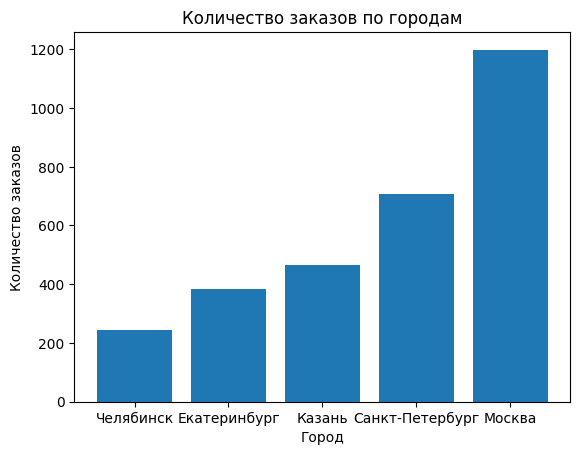

In [ ]:
s6 = df.groupby("city")["order_id"].count().sort_values()
plt.bar(s6.index, s6.values)
plt.title("Количество заказов по городам")
plt.ylabel("Количество заказов")
plt.xlabel("Город")
plt.show()

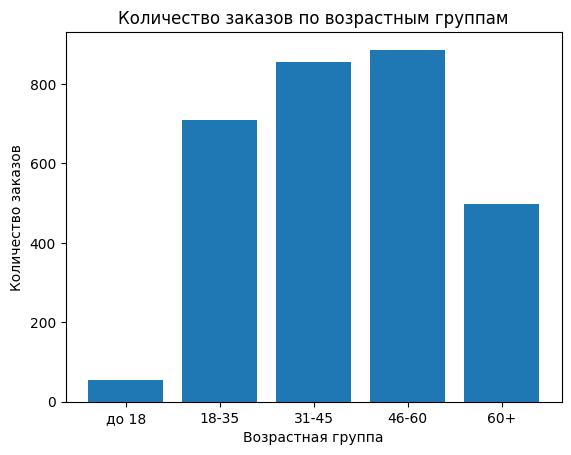

In [ ]:
s7 = df["age_group"].value_counts().reindex(labels)
plt.bar(s7.index, s7.values)
plt.title("Количество заказов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.show()

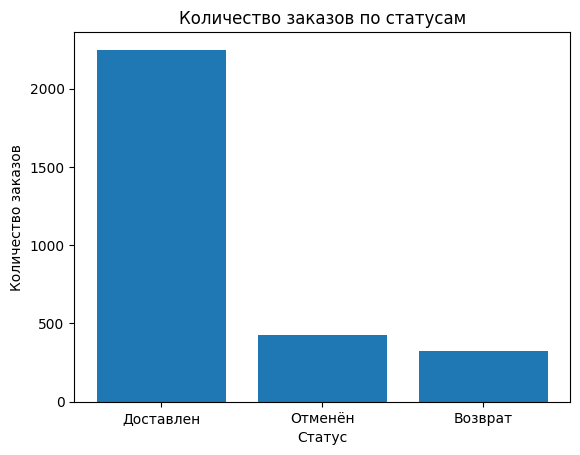

In [ ]:
s8 = df["status"].value_counts()
plt.bar(s8.index, s8.values)
plt.title("Количество заказов по статусам")
plt.xlabel("Статус")
plt.ylabel("Количество заказов")
plt.show()

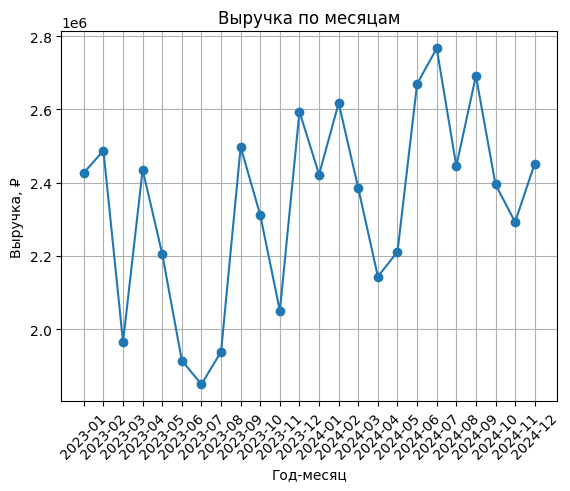

In [ ]:
monthly = df.groupby(["year", "month"])["revenue"].sum()

monthly.index = [f"{y}-{m:02d}" for y, m in monthly.index]

plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Выручка по месяцам")
plt.xlabel("Год-месяц")
plt.ylabel("Выручка, ₽")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Часть 6. Мини-анализ

In [ ]:
print(len(df))
print(df['revenue'].sum())
print(df['revenue'].mean())

3000
56176171.655499995
18725.39055183333


Набор содержит 3000 заказов, их суммарная выручка — около 5,62 млн рублей, что даёт среднюю выручку на заказ примерно 18 725 рублей.

In [ ]:
df.groupby('category')['revenue'].sum()

,revenue
category,
Дом,1.184381e+07
Красота,1.035824e+07
Одежда,1.094603e+07
Спорт,1.237715e+07
Электроника,1.065094e+07


Наибольшую суммарную выручку приносит категория «Спорт» — 12,38 млн рублей, наименьшую — «Красота» — 10,36 млн рублей.

In [ ]:
vip_revenue   = df.loc[df["is_vip"], "revenue"].sum()
total_revenue = df["revenue"].sum()
vip_share     = vip_revenue / total_revenue

print(vip_revenue)
print(total_revenue)
print(vip_share * 100)

10990942.1214
56176171.655499995
19.565131972327844


VIP-клиенты приносят около 19,6 % всей выручки

In [ ]:
df["discount_group"] = pd.cut(
    df["discount"],
    bins=[-1, 0.05, 0.15, 0.25, 0.4],
    labels=["0-5%", "5-15%", "15-25%", "25-40%"],
)

df.groupby('discount_group')['revenue'].mean()

/tmp/ipykernel_658/925988073.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('discount_group')['revenue'].mean()


,revenue
discount_group,
0-5%,22087.335289
5-15%,20492.380260
15-25%,18358.064318
25-40%,16154.329650


чем больше скидка, тем меньше средняя выручка

In [ ]:
df.groupby(["category", "status"])["order_id"].count().unstack(fill_value=0)

status,Возврат,Доставлен,Отменён
category,,,
Дом,56,481,84
Красота,64,441,87
Одежда,63,431,78
Спорт,72,463,90
Электроника,68,433,89


Вне зависимости от категории возвращено примерно 10% заказов и 15% - отменено

# Часть 7. Итоговый вывод

В наборе 3000 заказов с суммарной выручкой около 5,62 млн рублей и средним чеком 18 725 рублей. По выручке лидирует категория «Спорт» (12,38 млн), замыкает список «Красота» (10,36 млн), причём разрыв между категориями небольшой. Основной поток заказов приходится на Москву, что соответствует заданному распределению по городам. VIP-клиенты обеспечивают 19,6 % выручки, что совпадает с их долей в заказах, — значит, статус VIP в данных не влияет на средний чек. Скидки снижают средний чек, но не препятствуют росту суммарной выручки за счёт количества заказов; отмены и возвраты распределены по категориям равномерно.